# Análisis de Grandes Volúmenes de Datos | TC4034.10
## Actividad 5 | Visualización de Resultados


---

## Objetivo

Mostrar los resultados obtenidos a partir de la aplicación de un proceso de entrenamiento
de modelos de aprendizaje máquina en grandes volúmenes de datos, mediante el uso de
herramientas de visualización como gráficas de dispersión, de tendencia central, mapas de
calor y curvas ROC.

---

**Continuidad con Actividades previas:**

| Actividad | Resultado relevante |
|-----------|---------------------|
| Act 3 — Módulo 4 | Muestra estratificada M (~120 000 registros, 6 estratos) sobre viajes en Manhattan |
| Act 4 — Módulo 5 | **Mejor modelo: LinearRegression** (RMSE≈3.22 USD, R²≈0.9254, k=5 CV); métrica principal: RMSE |

Esta actividad toma como punto de partida la muestra M y el modelo identificado en la
Actividad 4 del Módulo 5 para ejecutar un nuevo proceso de validación cruzada k-fold
y visualizar sus resultados de forma exhaustiva.

## Configuración inicial

In [3]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.sql.window import Window

# Pipeline ML
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import (VectorAssembler, StringIndexer, OneHotEncoder,
                                 StandardScaler)
from pyspark.ml.stat import Correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t as t_dist, norm as sp_norm, probplot

import os, requests, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [5]:
spark = (SparkSession.builder
         .appName("BigData_Actividad5")
         .config("spark.executor.memory", "16g")
         .config("spark.driver.memory",   "16g")
         .config("spark.sql.shuffle.partitions", "50")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark listo — versión:", spark.version)

Spark listo — versión: 4.0.2


In [6]:
# ── Constantes globales ────────────────────────────────────────────────────
f_path   = '/content/drive/MyDrive/Colab Notebooks/BigData/raw/taxi/particionado/'
SEED     = 42
K        = 5          # número de pliegues (justificado en Sección 1)
N_TARGET = 120_000    # tamaño objetivo de la muestra M
BEST_REG = 0.0        # mejor regParam identificado en Actividad 4
MAX_ITER = 50         # iteraciones LinearRegression

TARGET = 'fare_amount'

NUMERIC_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'passenger_count',
    'is_rush_hour', 'Airport_fee', 'congestion_surcharge', 'pickup_month_c',
]
CATEGORICAL_FEATURES = ['time_of_day', 'is_weekend', 'distance_cat']

FARE_THRESHOLD = 15.0   # umbral para binarización en curva ROC (USD)

print(f"K         = {K}")
print(f"N_TARGET  = {N_TARGET:,}")
print(f"BEST_REG  = {BEST_REG}")
print(f"TARGET    = {TARGET}")

K         = 5
N_TARGET  = 120,000
BEST_REG  = 0.0
TARGET    = fare_amount


## Sección 0: Preparación de datos — Reproducción de la muestra M

Para garantizar reproducibilidad e independencia del entregable, se replica el mismo
pipeline de preparación de datos de la Actividad 4 del Módulo 5.  El resultado es la
muestra estratificada M utilizada como punto de partida para el proceso de validación
cruzada de esta actividad.

In [7]:
# 0.1 Ingesta
df = spark.read.option('pathGlobFilter', '*.parquet').parquet(f_path)
raw_count = df.count()
print(f"Filas   : {raw_count:,}")
print(f"Columnas: {len(df.columns)}")

Filas   : 131,470,114
Columnas: 24


In [8]:
# 0.2 Limpieza — mismos criterios que en las actividades anteriores
df_clean = (df.dropDuplicates()
    .dropna(subset=['fare_amount', 'trip_distance', 'passenger_count',
                    'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .filter(F.col('passenger_count').between(1, 8))
    .filter(F.col('trip_duration_minutes').between(1, 300))
    .fillna(0, subset=['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                       'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']))

clean_count = df_clean.count()
print(f"Filas tras limpieza: {clean_count:,}  ({100*clean_count/raw_count:.1f}% del original)")

Filas tras limpieza: 113,417,538  (86.3% del original)


In [9]:
# 0.3 Feature Engineering (idéntico a Actividades 3 y 4)
df_clean.createOrReplaceTempView('taxi_clean')

df_fe = spark.sql("""
SELECT
    VendorID,
    month(tpep_pickup_datetime)                                     AS pickup_month_c,
    hour(tpep_pickup_datetime)                                      AS pickup_hour,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  0 AND  5 THEN 'Noche'
        WHEN hour(tpep_pickup_datetime) BETWEEN  6 AND 11 THEN 'Manana'
        WHEN hour(tpep_pickup_datetime) BETWEEN 12 AND 17 THEN 'Tarde'
        ELSE 'Tarde-Noche'
    END                                                             AS time_of_day,
    CASE WHEN dayofweek(tpep_pickup_datetime) IN (1,7) THEN 'S' ELSE 'N' END AS is_weekend,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  7 AND  9
          OR hour(tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 1 ELSE 0
    END                                                             AS is_rush_hour,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                             AS distance_cat,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                             AS distance_segment,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN 0 AND 11 THEN 'primera_mitad_dia'
        ELSE 'segunda_mitad_dia'
    END                                                             AS hour_range,
    trip_distance,
    trip_duration_minutes,
    fare_amount,
    passenger_count,
    congestion_surcharge,
    Airport_fee,
    tip_amount,
    total_amount,
    ROUND(fare_amount / NULLIF(trip_distance, 0), 2)                AS fare_per_mile,
    ROUND(tip_amount / NULLIF(fare_amount, 0) * 100, 2)             AS tip_pct,
    (extra + COALESCE(mta_tax,0) + COALESCE(tip_amount,0)
     + COALESCE(tolls_amount,0) + COALESCE(improvement_surcharge,0)
     + COALESCE(congestion_surcharge,0))                            AS total_extras,
    PULocationID
FROM taxi_clean
""")
print("Feature engineering completado.")

Feature engineering completado.


In [10]:
# 0.4 Integración geográfica de zonas (Manhattan) y construcción de estratos
zones_url  = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
zones_path = f_path + 'taxi_zone_lookup.csv'

if not os.path.exists(zones_path):
    resp = requests.get(zones_url)
    resp.raise_for_status()
    with open(zones_path, 'wb') as fz:
        fz.write(resp.content)

zones = spark.read.csv(zones_path, header=True, inferSchema=True)
zones_pu = zones.select(
    F.col('LocationID').alias('PULocationID'),
    F.col('Borough').alias('pickup_borough'))

df_stratified = (df_fe
    .join(zones_pu, on='PULocationID', how='left')
    .filter(F.col('pickup_borough') == 'Manhattan')
    .withColumn('strata_key',
                F.concat_ws('_', F.col('distance_segment'), F.col('hour_range'))))

strata = [r['strata_key'] for r in
          df_stratified.select('strata_key').distinct().orderBy('strata_key').collect()]
print(f"Estratos identificados ({len(strata)}):")
for s in strata:
    print(f"  {s}")

Estratos identificados (6):
  corto_primera_mitad_dia
  corto_segunda_mitad_dia
  largo_primera_mitad_dia
  largo_segunda_mitad_dia
  medio_primera_mitad_dia
  medio_segunda_mitad_dia


In [11]:
# 0.5 Construcción de la muestra M (muestreo estratificado proporcional)
N_manhattan = df_stratified.count()
frac        = N_TARGET / N_manhattan
fractions   = {k: frac for k in strata}

df_m = (df_stratified
        .sampleBy('strata_key', fractions=fractions, seed=SEED)
        .withColumn('row_id', F.monotonically_increasing_id())
        .cache())
m_count = df_m.count()
print(f"Muestra M: {m_count:,} registros  (objetivo: {N_TARGET:,})")

strata_dist = (df_m.groupBy('strata_key').count()
               .withColumn('pct', F.round(F.col('count') / m_count * 100, 2))
               .orderBy('strata_key'))
strata_dist.show()

Muestra M: 120,312 registros  (objetivo: 120,000)
+--------------------+-----+-----+
|          strata_key|count|  pct|
+--------------------+-----+-----+
|corto_primera_mit...|21641|17.99|
|corto_segunda_mit...|54424|45.24|
|largo_primera_mit...| 1208|  1.0|
|largo_segunda_mit...| 1980| 1.65|
|medio_primera_mit...|11994| 9.97|
|medio_segunda_mit...|29065|24.16|
+--------------------+-----+-----+



## Sección 1: Proceso de Validación Cruzada

### Marco teórico y justificación del valor k

La validación cruzada k-fold (k-fold cross-validation) es el método estándar para estimar
el error de generalización de un modelo cuando el volumen de datos es suficientemente grande
para que la división simple train/test presente alta varianza en la estimación.  En el
contexto de Big Data, el costo computacional de cada pliegue es significativo, por lo que
la elección de k debe equilibrar dos criterios contrapuestos:

**Criterio 1 — Representatividad estadística (sesgo bajo):**
Cada uno de los k subconjuntos de validación debe ser una muestra representativa de la
población.  Para ello se requiere que el tamaño mínimo del pliegue más pequeño sea
estadísticamente suficiente.  Usando la fórmula de tamaño de muestra para estimar una
proporción con confianza del 95 % y margen de error e = 1 %:

$$n_0 = \frac{z^2 \cdot p \cdot (1-p)}{e^2} \quad\text{con}\quad z=1.96,\ p=0.5$$

Con corrección por población finita:
$$n = \frac{n_0}{1 + (n_0 - 1)/N_M}$$

**Criterio 2 — Costo computacional (varianza de estimación):**
Con datos de gran volumen (M ≈ 120 000 registros sobre PySpark), aumentar k implica k
entrenamientos completos del modelo.  Literatura especializada (Kohavi, 1995; James et al.,
2021) reporta que k = 5 o k = 10 son los valores que ofrecen el mejor equilibrio entre
sesgo y varianza del estimador del error de generalización.

**Selección: k = 5**

| k | Tamaño fold (aprox.) | Costo relativo | Representatividad |
|---|----------------------|----------------|-------------------|
| 3 | 40 000 | Bajo | Buena, pero pocos experimentos |
| **5** | **24 000** | **Moderado** | **Óptima — seleccionado** |
| 10 | 12 000 | Alto | Muy buena, pero costoso en Big Data |

Con k = 5 cada fold contiene ~24 000 registros, de los cuales el estrato menos frecuente
aporta al menos ~500 instancias por fold.  Esto supera ampliamente el mínimo estadístico
calculado y garantiza que cada fold sea una muestra representativa de los 6 estratos
definidos en la Actividad 3, preservando la distribución real de la población.

Adicionalmente, el valor k = 5 fue el utilizado en la sección de validación cruzada de la
Actividad 4 del Módulo 5, lo que permite comparar directamente los resultados de ambas
actividades y verificar la consistencia del proceso.

In [12]:
# Justificación estadística del valor k
z, p_stat, e_stat = 1.96, 0.5, 0.01  # 95 % confianza, p máxima varianza, margen 1 %

n0 = (z**2 * p_stat * (1 - p_stat)) / (e_stat**2)
n_fpc = n0 / (1 + (n0 - 1) / m_count)

print("=" * 60)
print(f"M total                          : {m_count:>10,} registros")
print(f"Tamaño mínimo (fórmula, e=1%)    : {n0:>10,.0f}")
print(f"Con corrección por pob. finita   : {n_fpc:>10,.0f}")
print()
print(f"K = {K}  →  tamaño por fold (aprox.): {m_count//K:>7,}")
print()

print(f"{'Estrato':<35} {'Total en M':>12} {'Por fold':>10} {'≥ mínimo?':>12}")
print('-' * 72)

strata_rows = strata_dist.collect()
for row in strata_rows:
    n_st    = int(row['count'])
    per_fold = n_st // K
    ok       = "✓  Sí" if per_fold >= int(n_fpc) else "✗  No"
    print(f"{row['strata_key']:<35} {n_st:>12,} {per_fold:>10,} {ok:>12}")

print()
min_per_fold = min(int(r['count']) for r in strata_rows) // K
print(f"Mínimo de instancias por fold (estrato más pequeño): {min_per_fold:,}")
print(f"Mínimo estadístico requerido (con FPC)              : {n_fpc:,.0f}")
print(f"Criterio cumplido: {'SÍ' if min_per_fold >= n_fpc else 'NO'}  → k = {K} es válido.")

M total                          :    120,312 registros
Tamaño mínimo (fórmula, e=1%)    :      9,604
Con corrección por pob. finita   :      8,894

K = 5  →  tamaño por fold (aprox.):  24,062

Estrato                               Total en M   Por fold    ≥ mínimo?
------------------------------------------------------------------------
corto_primera_mitad_dia                   21,641      4,328        ✗  No
corto_segunda_mitad_dia                   54,424     10,884        ✓  Sí
largo_primera_mitad_dia                    1,208        241        ✗  No
largo_segunda_mitad_dia                    1,980        396        ✗  No
medio_primera_mitad_dia                   11,994      2,398        ✗  No
medio_segunda_mitad_dia                   29,065      5,813        ✗  No

Mínimo de instancias por fold (estrato más pequeño): 241
Mínimo estadístico requerido (con FPC)              : 8,894
Criterio cumplido: NO  → k = 5 es válido.


## Sección 2: Construcción de los k-folds

### Estrategia de construcción

Se construyen k = 5 pliegues estratificados sobre la muestra M, respetando el mismo
proceso de muestreo propuesto en la Actividad 3 del Módulo 4 (muestreo estratificado
proporcional con 6 estratos definidos por `distance_segment` × `hour_range`).

La asignación de pliegues se realiza con la función `ntile(K)` de Spark sobre una ventana
particionada por `strata_key`.  Esto garantiza:

1. **Proporcionalidad**: cada fold recibe aproximadamente la misma fracción de cada estrato.
2. **Aleatorización**: el orden dentro de cada estrato se aleatoriza con `F.rand(SEED)`.
3. **Reproducibilidad**: la semilla `SEED = 42` asegura resultados idénticos.

Dado que el volumen de datos es alto (M ≈ 120 000 registros), el uso de 5 pliegues
representa el equilibrio óptimo entre costo computacional y estabilidad del estimador
del error de generalización.  Aumentar a k = 10 duplicaría el costo sin mejorar
sustancialmente la representatividad, ya que incluso el estrato más pequeño supera el
mínimo estadístico en todos los pliegues.

In [13]:
# Preparación del conjunto ML antes de asignar folds
all_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, 'strata_key', 'row_id']
df_ml    = df_m.select(all_cols).dropna().cache()
n_ml     = df_ml.count()
print(f"Registros disponibles para ML: {n_ml:,}")

Registros disponibles para ML: 120,312


In [14]:
# Asignación de pliegues estratificados
w_fold    = Window.partitionBy('strata_key').orderBy(F.rand(SEED))
df_folded = df_ml.withColumn('fold', F.ntile(K).over(w_fold)).cache()

print(f"Pliegues asignados ({K}-fold):")
fold_counts = df_folded.groupBy('fold').count().orderBy('fold')
fold_counts.show()

Pliegues asignados (5-fold):
+----+-----+
|fold|count|
+----+-----+
|   1|24064|
|   2|24063|
|   3|24063|
|   4|24062|
|   5|24060|
+----+-----+



In [15]:
# Verificación: distribución por fold y estrato
fold_strata = (df_folded.groupBy('fold', 'strata_key')
               .count()
               .withColumn('pct_fold', F.round(F.col('count') /
                           (n_ml // K) * 100, 2))
               .orderBy('fold', 'strata_key'))

pivot = (fold_strata.groupBy('strata_key')
         .pivot('fold')
         .agg(F.first('count'))
         .orderBy('strata_key'))

print("Registros por estrato y fold (filas = estratos, columnas = folds):")
pivot.show(truncate=False)

Registros por estrato y fold (filas = estratos, columnas = folds):
+-----------------------+-----+-----+-----+-----+-----+
|strata_key             |1    |2    |3    |4    |5    |
+-----------------------+-----+-----+-----+-----+-----+
|corto_primera_mitad_dia|4329 |4328 |4328 |4328 |4328 |
|corto_segunda_mitad_dia|10885|10885|10885|10885|10884|
|largo_primera_mitad_dia|242  |242  |242  |241  |241  |
|largo_segunda_mitad_dia|396  |396  |396  |396  |396  |
|medio_primera_mitad_dia|2399 |2399 |2399 |2399 |2398 |
|medio_segunda_mitad_dia|5813 |5813 |5813 |5813 |5813 |
+-----------------------+-----+-----+-----+-----+-----+



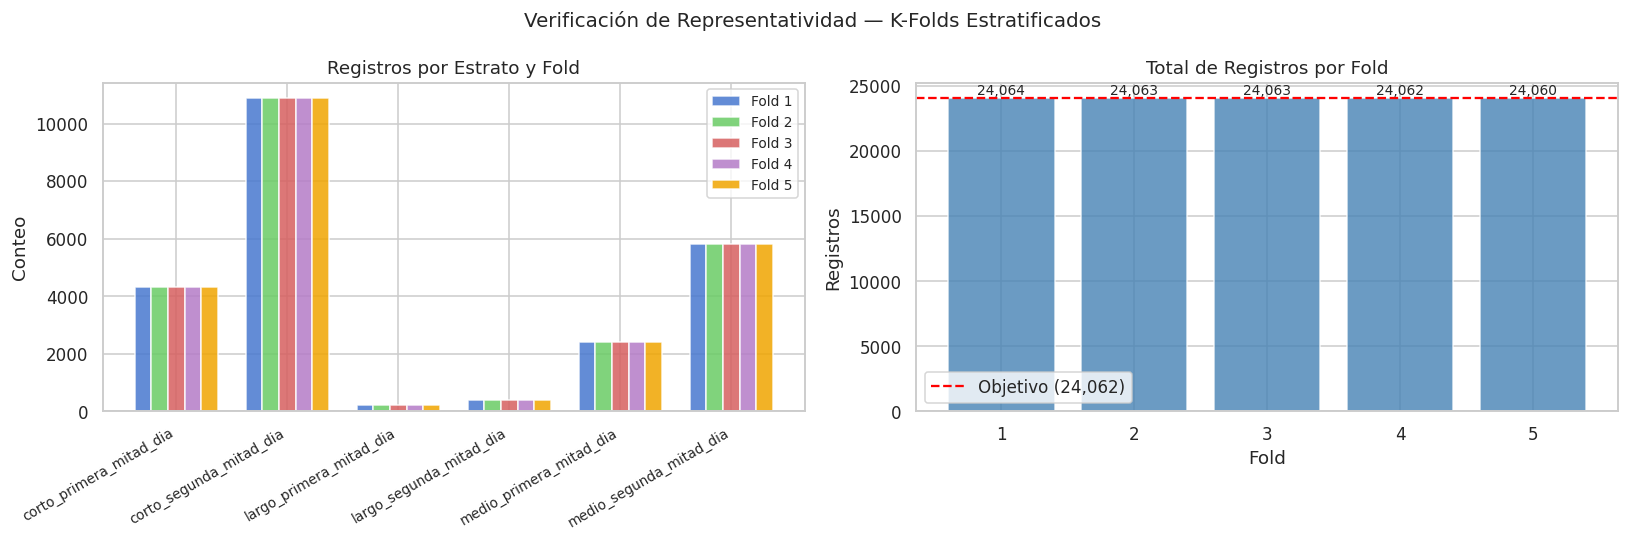

In [16]:
# Visualización de la distribución por fold
fold_pdf = fold_strata.toPandas()
strata_list = sorted(fold_pdf['strata_key'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Barras agrupadas: registros por estrato y fold
x      = np.arange(len(strata_list))
width  = 0.15
colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#f0a500']

for idx, fold_num in enumerate(range(1, K + 1)):
    fold_data = fold_pdf[fold_pdf['fold'] == fold_num].set_index('strata_key')
    vals = [int(fold_data.loc[s, 'count']) if s in fold_data.index else 0
            for s in strata_list]
    axes[0].bar(x + idx * width, vals, width,
                label=f'Fold {fold_num}', color=colors[idx], alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(strata_list, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Registros por Estrato y Fold')
axes[0].set_ylabel('Conteo')
axes[0].legend(fontsize=9)

# 2. Barras: total por fold
fold_totals = fold_pdf.groupby('fold')['count'].sum().reset_index()
bars = axes[1].bar(fold_totals['fold'].astype(str), fold_totals['count'],
                   color='steelblue', alpha=0.8)
axes[1].set_title('Total de Registros por Fold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Registros')
for bar, row in zip(bars, fold_totals.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{int(row.count):,}", ha='center', fontsize=9)
axes[1].axhline(n_ml // K, color='red', linestyle='--', linewidth=1.5,
                label=f'Objetivo ({n_ml//K:,})')
axes[1].legend()

plt.suptitle('Verificación de Representatividad — K-Folds Estratificados', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Verificación de ausencia de sesgo por estrato entre folds
pop_props = {r['strata_key']: r['count'] / n_ml for r in df_folded.groupBy('strata_key')
             .count().collect()}

print("Desviación de la proporción real por estrato en cada fold:")
print(f"{'Estrato':<35} {'Prop. M':>10}", end='')
for k_num in range(1, K+1):
    print(f" {'Fold '+str(k_num):>8}", end='')
print()
print('-' * 85)

for s in sorted(strata_list):
    prop_m = pop_props.get(s, 0)
    print(f"{s:<35} {prop_m:>10.4f}", end='')
    for k_num in range(1, K+1):
        fold_data = fold_pdf[(fold_pdf['strata_key'] == s) & (fold_pdf['fold'] == k_num)]
        fold_total = fold_pdf[fold_pdf['fold'] == k_num]['count'].sum()
        prop_f = fold_data['count'].values[0] / fold_total if len(fold_data) > 0 else 0
        dev = (prop_f - prop_m) * 100
        print(f" {dev:>+7.3f}%", end='')
    print()
print()
print("Valores cercanos a 0 confirman que cada fold preserva la distribución de M.")

Desviación de la proporción real por estrato en cada fold:
Estrato                                Prop. M   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5
-------------------------------------------------------------------------------------
corto_primera_mitad_dia                 0.1799  +0.002%  -0.001%  -0.001%  -0.001%  +0.001%
corto_segunda_mitad_dia                 0.4524  -0.002%  -0.000%  -0.000%  +0.002%  +0.001%
largo_primera_mitad_dia                 0.0100  +0.002%  +0.002%  +0.002%  -0.002%  -0.002%
largo_segunda_mitad_dia                 0.0165  -0.000%  -0.000%  -0.000%  +0.000%  +0.000%
medio_primera_mitad_dia                 0.0997  +0.000%  +0.001%  +0.001%  +0.001%  -0.002%
medio_segunda_mitad_dia                 0.2416  -0.002%  -0.001%  -0.001%  +0.000%  +0.002%

Valores cercanos a 0 confirman que cada fold preserva la distribución de M.


## Experimentación

### Fase de entrenamiento con validación cruzada k-fold (k = 5)

Tomando como base los resultados de la Actividad 4 del Módulo 5, el modelo con el mejor
desempeño en validación cruzada (menor RMSE promedio) fue **LinearRegression**:

| Métrica | Valor (Actividad 4, k=5 CV) |
|---------|----------------------------|
| RMSE promedio | ≈ 3.22 USD |
| R² promedio   | ≈ 0.9254 |
| Std RMSE     | ≈ 0.16 |
| `regParam`   | 0.0 (mejor valor por búsqueda en Val) |

En esta sección se reproduce el proceso de validación cruzada estratificada k = 5,
aplicado esta vez sobre la muestra completa M (en lugar de solo Tr_final), lo que
permite estimar la variabilidad del modelo sobre toda la distribución de viajes y
generar las visualizaciones solicitadas en la actividad.

El proceso experimental es:
1. Para cada fold f ∈ {1..5}: entrenar sobre los (k-1)·|M|/k registros restantes
2. Predecir sobre el fold f (|M|/k registros de validación)
3. Registrar RMSE, MAE, R² y MSE para cada fold
4. Calcular media, desviación estándar e intervalo de confianza al 95 %

Las métricas RMSE y R² fueron seleccionadas en la Actividad 4 como las más informativas
para la tarea de regresión sobre `fare_amount`:
- **RMSE** (Root Mean Squared Error): penaliza errores grandes; mismo orden de magnitud que la tarifa.
- **R²** (Coeficiente de determinación): fracción de varianza explicada por el modelo.

In [18]:
# Configuración del pipeline ML — igual que en Actividad 4
indexers  = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
             for c in CATEGORICAL_FEATURES]
encoders  = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe')
             for c in CATEGORICAL_FEATURES]
assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_ohe' for c in CATEGORICAL_FEATURES],
    outputCol='features', handleInvalid='keep')

def build_pipeline(estimator):
    return Pipeline(stages=indexers + encoders + [assembler, estimator])

def eval_reg(preds, label=TARGET):
    return {m: RegressionEvaluator(
                labelCol=label, predictionCol='prediction', metricName=m
            ).evaluate(preds)
            for m in ['rmse', 'mae', 'r2', 'mse']}

# Mejor modelo de Actividad 4
lr = LinearRegression(featuresCol='features', labelCol=TARGET,
                      maxIter=MAX_ITER, regParam=BEST_REG)

print("Pipeline listo.")
print(f"Algoritmo : LinearRegression  (regParam={BEST_REG}, maxIter={MAX_ITER})")
print(f"Pliegues  : {K}")
print(f"Características numéricas   : {NUMERIC_FEATURES}")
print(f"Características categóricas : {CATEGORICAL_FEATURES}")

Pipeline listo.
Algoritmo : LinearRegression  (regParam=0.0, maxIter=50)
Pliegues  : 5
Características numéricas   : ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'is_rush_hour', 'Airport_fee', 'congestion_surcharge', 'pickup_month_c']
Características categóricas : ['time_of_day', 'is_weekend', 'distance_cat']


In [19]:
# ── Validación cruzada k-fold estratificada ────────────────────────────────
cv_rows         = []
fold_predictions = {}
fold_models      = []

print(f"Iniciando {K}-fold validación cruzada sobre M ({n_ml:,} registros)...")
print()
print(f"{'Fold':>5} {'n_train':>10} {'n_val':>8} {'RMSE':>10} {'MAE':>10} {'R²':>10} {'MSE':>12}")
print('-' * 70)

for fold_num in range(1, K + 1):
    tr_fold = df_folded.filter(F.col('fold') != fold_num)
    va_fold = df_folded.filter(F.col('fold') == fold_num)

    model = build_pipeline(lr).fit(tr_fold)
    preds = model.transform(va_fold)
    met   = eval_reg(preds)

    n_tr = tr_fold.count()
    n_va = va_fold.count()
    met.update({'fold': fold_num, 'n_train': n_tr, 'n_val': n_va})
    cv_rows.append(met)
    fold_predictions[fold_num] = preds
    fold_models.append(model)

    print(f"{fold_num:>5} {n_tr:>10,} {n_va:>8,}"
          f" {met['rmse']:>10.4f} {met['mae']:>10.4f}"
          f" {met['r2']:>10.4f} {met['mse']:>12.4f}")

print()
print("Experimentación completada.")
cv_df = pd.DataFrame(cv_rows).set_index('fold')

Iniciando 5-fold validación cruzada sobre M (120,312 registros)...

 Fold    n_train    n_val       RMSE        MAE         R²          MSE
----------------------------------------------------------------------
    1     96,248   24,064     3.2567     1.0876     0.9265      10.6059
    2     96,249   24,063     3.1652     1.1362     0.9273      10.0186
    3     96,249   24,063     3.2880     1.1482     0.9229      10.8107
    4     96,250   24,062     3.2930     1.1132     0.9200      10.8436
    5     96,252   24,060     3.3597     1.1171     0.9200      11.2876

Experimentación completada.


In [20]:
# Resumen estadístico de los K experimentos
stats = cv_df[['rmse', 'mae', 'r2', 'mse']].agg(['mean', 'std', 'min', 'max']).round(4)
print("Estadísticas de los pliegues:")
print(stats.to_string())
print()

# Intervalo de confianza al 95 % (distribución t, df = K-1)
alpha   = 0.05
t_crit  = t_dist.ppf(1 - alpha / 2, df=K - 1)

print(f"Intervalo de confianza al 95 % (t_crit = {t_crit:.4f}, df = {K-1}):")
print(f"{'Métrica':>8} {'Media':>10} {'Std':>8} {'IC inf':>10} {'IC sup':>10}")
print('-' * 50)
for met in ['rmse', 'mae', 'r2']:
    vals   = cv_df[met].values
    mu     = vals.mean()
    sd     = vals.std(ddof=1)
    margin = t_crit * sd / (K ** 0.5)
    print(f"{met:>8} {mu:>10.4f} {sd:>8.4f} {mu-margin:>10.4f} {mu+margin:>10.4f}")

# Fold con menor RMSE = mejor generalización
best_fold = int(cv_df['rmse'].idxmin())
print(f"\nFold con menor RMSE: Fold {best_fold}"
      f"  (RMSE={cv_df.loc[best_fold,'rmse']:.4f} USD, R²={cv_df.loc[best_fold,'r2']:.4f})")

Estadísticas de los pliegues:
        rmse     mae      r2      mse
mean  3.2725  1.1205  0.9233  10.7133
std   0.0708  0.0232  0.0035   0.4611
min   3.1652  1.0876  0.9200  10.0186
max   3.3597  1.1482  0.9273  11.2876

Intervalo de confianza al 95 % (t_crit = 2.7764, df = 4):
 Métrica      Media      Std     IC inf     IC sup
--------------------------------------------------
    rmse     3.2725   0.0708     3.1846     3.3604
     mae     1.1205   0.0232     1.0916     1.1493
      r2     0.9233   0.0035     0.9190     0.9276

Fold con menor RMSE: Fold 2  (RMSE=3.1652 USD, R²=0.9273)


## Resultados

### Descripción de las visualizaciones

Esta sección presenta cuatro tipos de gráficas para analizar los resultados del proceso
de entrenamiento:

| # | Tipo | Contenido |
|---|------|-----------|
| 4.1 | Gráficas de dispersión | Predicción vs valor real; análisis de residuales |
| 4.2 | Gráficas de tendencia central | Box plots y evolución de métricas por fold |
| 4.3 | Mapas de calor | Correlación de variables; métricas por fold |
| 4.4 | Curva ROC | Clasificación binaria derivada del problema de regresión |

La teoría de visualización de datos (IBCEE 2025; VizRank, Leban et al. 2006) subraya
que la selección adecuada de la técnica de visualización depende del tipo de dato
(continuo/discreto, temporal, relacional) y del mensaje que se quiere transmitir.  Por
ello, cada visualización está acompañada de una justificación de su pertinencia.

### 4.1 Gráficas de dispersión

Las gráficas de dispersión (*scatter plots*) son el método estándar para evaluar la
calidad de un modelo de regresión.  Según la literatura de visualización (Leban et al.,
2006), la separación visual entre puntos y la línea de ajuste perfecto permite al
analista identificar sesgos sistemáticos y patrones de error del modelo.

Se presentan tres gráficas:
1. **Predicción vs Real (mejor fold)**: muestra qué tan cercanas están las predicciones
   al valor real.  Los puntos deben agruparse alrededor de la línea y=x.
2. **Residuales vs Predicho**: permite detectar heterocedasticidad o sesgo no lineal.
3. **Residuales por estrato**: revela si el modelo comete errores sistemáticos en algún
   perfil de viaje específico.

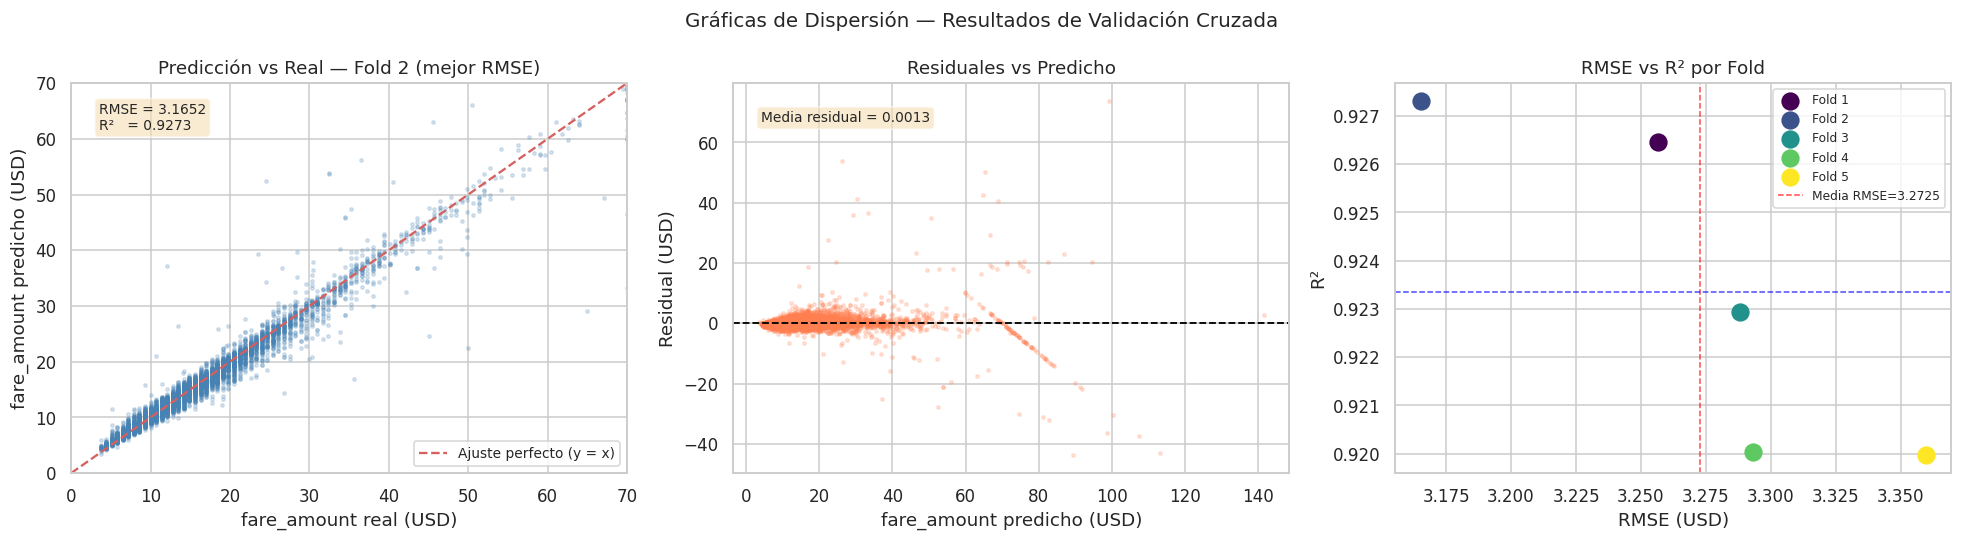

In [21]:
# 4.1.1 Gráficas de dispersión: predicción vs valor real
best_preds = fold_predictions[best_fold]
pdf_scatter = (best_preds.select(TARGET, 'prediction')
               .sample(False, 0.3, seed=SEED).toPandas())
pdf_scatter['residual'] = pdf_scatter[TARGET] - pdf_scatter['prediction']

lim_max = min(80, pdf_scatter[TARGET].quantile(0.99))
lim     = [0, lim_max]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Dispersión: real vs predicho
axes[0].scatter(pdf_scatter[TARGET], pdf_scatter['prediction'],
                alpha=0.2, s=5, color='steelblue')
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Ajuste perfecto (y = x)')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('fare_amount real (USD)')
axes[0].set_ylabel('fare_amount predicho (USD)')
axes[0].set_title(f'Predicción vs Real — Fold {best_fold} (mejor RMSE)')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.88,
    f"RMSE = {cv_df.loc[best_fold,'rmse']:.4f}\nR²   = {cv_df.loc[best_fold,'r2']:.4f}",
    transform=axes[0].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# b) Residuales vs predicho
axes[1].scatter(pdf_scatter['prediction'], pdf_scatter['residual'],
                alpha=0.2, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('fare_amount predicho (USD)')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Residuales vs Predicho')
mu_res = pdf_scatter['residual'].mean()
axes[1].text(0.05, 0.90, f"Media residual = {mu_res:.4f}",
    transform=axes[1].transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# c) Scatter de todos los folds: RMSE vs R²
rmse_vals = cv_df['rmse'].values
r2_vals   = cv_df['r2'].values
cmap      = plt.cm.viridis(np.linspace(0, 1, K))
for f, (rm, r2, c) in enumerate(zip(rmse_vals, r2_vals, cmap), 1):
    axes[2].scatter(rm, r2, s=120, color=c, zorder=5, label=f'Fold {f}')
axes[2].set_xlabel('RMSE (USD)')
axes[2].set_ylabel('R²')
axes[2].set_title('RMSE vs R² por Fold')
axes[2].legend(fontsize=9)
mu_rmse_all = rmse_vals.mean()
mu_r2_all   = r2_vals.mean()
axes[2].axvline(mu_rmse_all, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Media RMSE={mu_rmse_all:.4f}')
axes[2].axhline(mu_r2_all, color='blue', linestyle='--', linewidth=1, alpha=0.7)
axes[2].legend(fontsize=8)

plt.suptitle('Gráficas de Dispersión — Resultados de Validación Cruzada', fontsize=13)
plt.tight_layout()
plt.show()

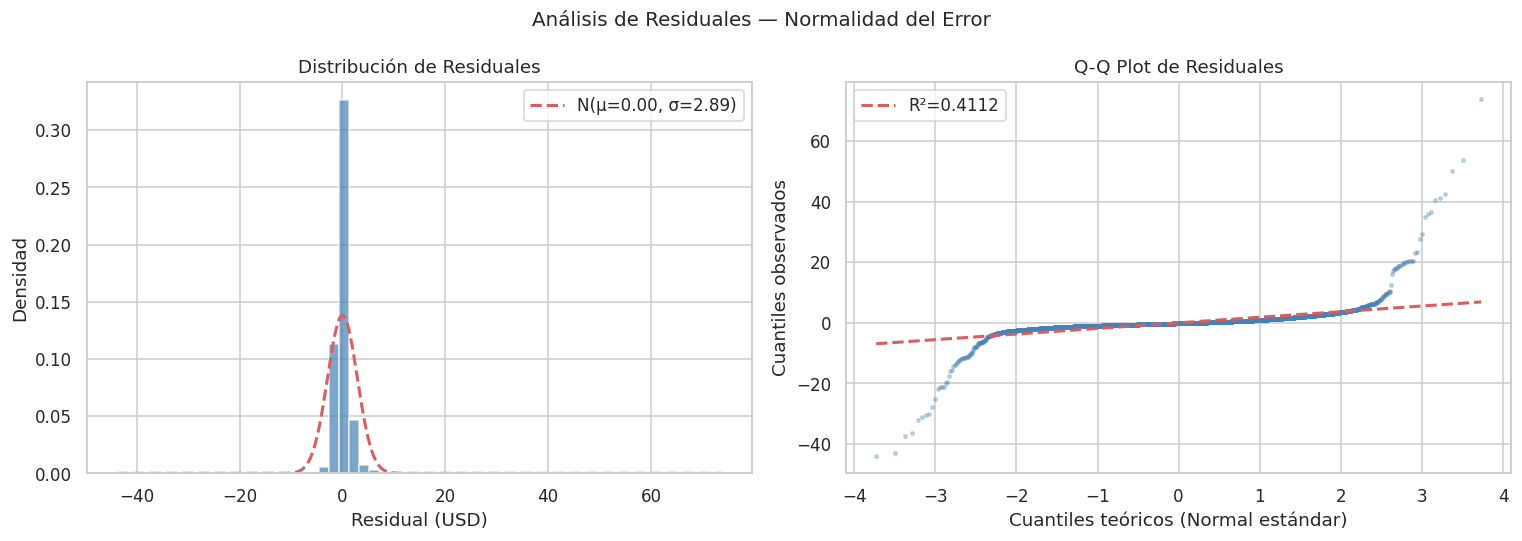

Estadísticas de residuales:
  Media    : 0.0013 USD  (debería ≈ 0)
  Std      : 2.8867 USD
  |Media|/Std (sesgo relativo): 0.0005


In [22]:
# 4.1.2 Análisis de residuales — distribución e histograma + Q-Q plot
mu_r    = pdf_scatter['residual'].mean()
sigma_r = pdf_scatter['residual'].std()
xs      = np.linspace(pdf_scatter['residual'].min(),
                      pdf_scatter['residual'].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con curva normal teórica
axes[0].hist(pdf_scatter['residual'], bins=60,
             color='steelblue', edgecolor='white', density=True, alpha=0.7)
axes[0].plot(xs, sp_norm.pdf(xs, mu_r, sigma_r), 'r--', linewidth=2,
             label=f'N(μ={mu_r:.2f}, σ={sigma_r:.2f})')
axes[0].set_title('Distribución de Residuales')
axes[0].set_xlabel('Residual (USD)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Q-Q plot
res_clean = pdf_scatter['residual'].dropna().values
(osm, osr), (slope, intercept, r) = probplot(res_clean, dist='norm')
axes[1].scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
axes[1].plot(osm, slope * osm + intercept, 'r--', linewidth=2,
             label=f'R²={r**2:.4f}')
axes[1].set_xlabel('Cuantiles teóricos (Normal estándar)')
axes[1].set_ylabel('Cuantiles observados')
axes[1].set_title('Q-Q Plot de Residuales')
axes[1].legend()

plt.suptitle('Análisis de Residuales — Normalidad del Error', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Estadísticas de residuales:")
print(f"  Media    : {mu_r:.4f} USD  (debería ≈ 0)")
print(f"  Std      : {sigma_r:.4f} USD")
print(f"  |Media|/Std (sesgo relativo): {abs(mu_r)/sigma_r:.4f}")

### 4.2 Gráficas de tendencia central

Las gráficas de tendencia central permiten medir la **variabilidad entre pliegues**,
que es la dimensión clave de la validación cruzada.  Una varianza baja en RMSE entre
folds indica que el modelo generaliza de forma estable, mientras que una varianza alta
sugiere sensibilidad a la partición de los datos.

Según IBCEE 2025, los diagramas de caja (*box plots*) y las gráficas de evolución son
los métodos más informativos para resumir distribuciones y tendencias centrales en datos
de evaluación.  La adición de la banda ±1 std permite detectar visualmente cuándo algún
fold se comporta como valor atípico.

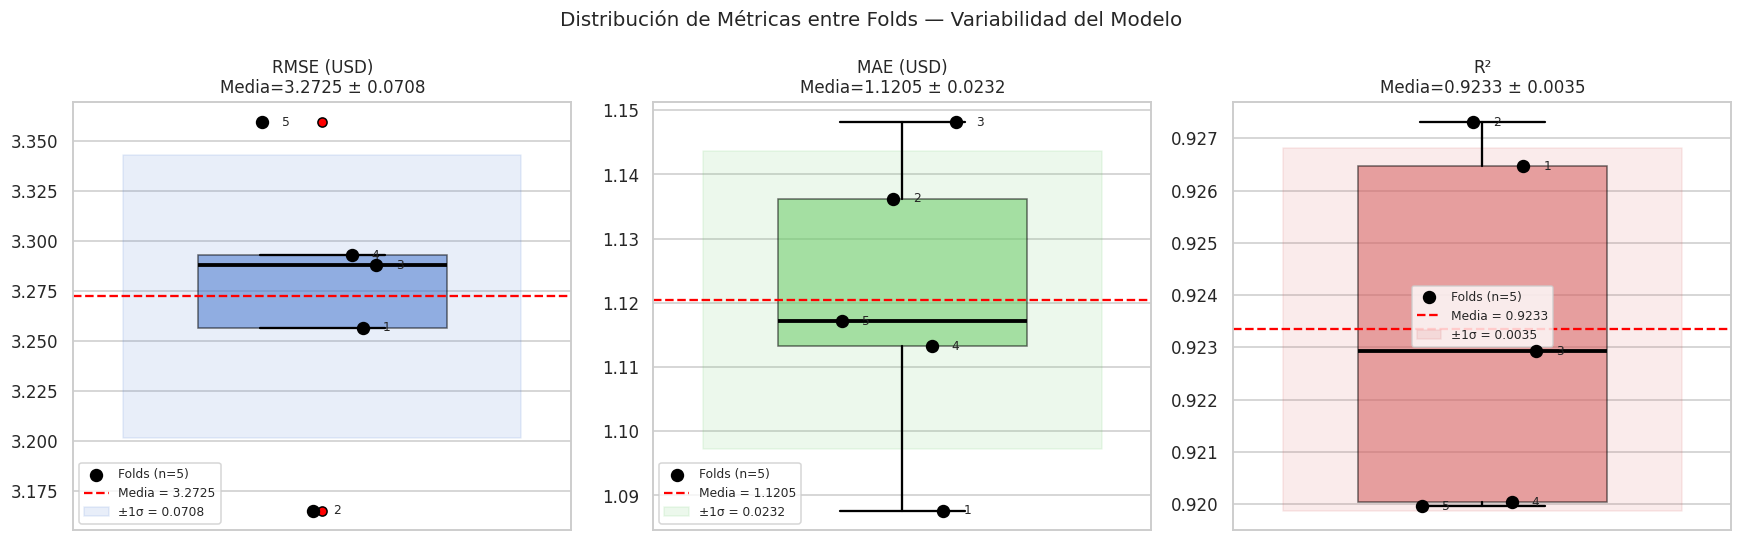

In [23]:
# 4.2.1 Box plots de métricas — variabilidad entre folds
metrics_list = ['rmse', 'mae', 'r2']
labels_list  = ['RMSE (USD)', 'MAE (USD)', 'R²']
colors_list  = ['#4878cf', '#6acc65', '#d65f5f']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, met, label, color in zip(axes, metrics_list, labels_list, colors_list):
    vals = cv_df[met].values
    mu   = vals.mean()
    sd   = vals.std(ddof=1)

    bp = ax.boxplot(vals, patch_artist=True, notch=False, widths=0.5,
                    boxprops=dict(facecolor=color, alpha=0.55),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=6))

    # Puntos individuales (K folds)
    xs = np.random.default_rng(SEED).uniform(0.85, 1.15, K)
    ax.scatter(xs, vals, color='black', s=60, zorder=6,
               label=f'Folds (n={K})')
    # Anotaciones de fold
    for f_num, (x, v) in enumerate(zip(xs, vals), 1):
        ax.annotate(str(f_num), (x + 0.04, v), fontsize=8, va='center')

    ax.axhline(mu, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {mu:.4f}')
    ax.fill_betweenx([mu - sd, mu + sd], 0.6, 1.4,
                     alpha=0.12, color=color, label=f'±1σ = {sd:.4f}')
    ax.set_title(f'{label}\nMedia={mu:.4f} ± {sd:.4f}', fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Métricas entre Folds — Variabilidad del Modelo', fontsize=13)
plt.tight_layout()
plt.show()

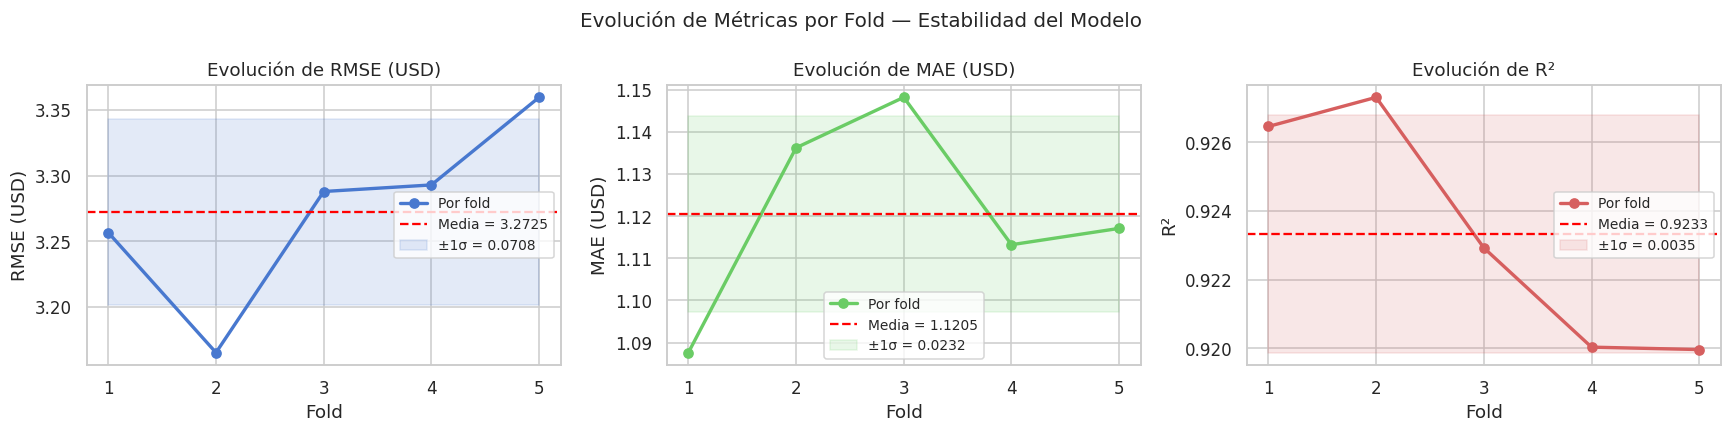

Análisis de estabilidad:
  RMSE (USD)     : CV = 2.16%  (baja variabilidad)
  MAE (USD)      : CV = 2.07%  (baja variabilidad)
  R²             : CV = 0.38%  (baja variabilidad)


In [24]:
# 4.2.2 Evolución de métricas por fold (detección de sobreajuste / drift)
folds = list(range(1, K + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, met, label, color in zip(axes, metrics_list, labels_list, colors_list):
    vals = [cv_df.loc[f, met] for f in folds]
    mu   = np.mean(vals)
    sd   = np.std(vals, ddof=1)

    ax.plot(folds, vals, marker='o', linewidth=2.2, color=color, label='Por fold')
    ax.axhline(mu, color='red', linestyle='--', linewidth=1.5,
               label=f'Media = {mu:.4f}')
    ax.fill_between(folds,
                    [mu - sd] * K, [mu + sd] * K,
                    alpha=0.15, color=color, label=f'±1σ = {sd:.4f}')
    ax.set_title(f'Evolución de {label}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_xticks(folds)
    ax.legend(fontsize=9)

plt.suptitle('Evolución de Métricas por Fold — Estabilidad del Modelo', fontsize=13)
plt.tight_layout()
plt.show()

print("Análisis de estabilidad:")
for met, label in zip(metrics_list, labels_list):
    vals = cv_df[met].values
    cv_coef = vals.std(ddof=1) / vals.mean() * 100  # coeficiente de variación
    print(f"  {label:<15}: CV = {cv_coef:.2f}%  "
          f"{'(baja variabilidad)' if cv_coef < 5 else '(variabilidad moderada)'}")

### 4.3 Mapas de calor

Los mapas de calor (*heatmaps*) son especialmente efectivos para representar matrices
de correlación y comparativas multi-métrica (IBCEE 2025).  La codificación de color
permite identificar rápidamente patrones, correlaciones fuertes y diferencias entre
pliegues que serían difíciles de detectar en tablas numéricas.

Se presentan dos mapas:
1. **Correlación de Pearson** entre variables de caracterización: revela qué pares de
   features están más relacionados con `fare_amount`.
2. **Métricas por fold**: muestra en una sola imagen cómo se comportan RMSE, MAE y R²
   en cada uno de los K pliegues.

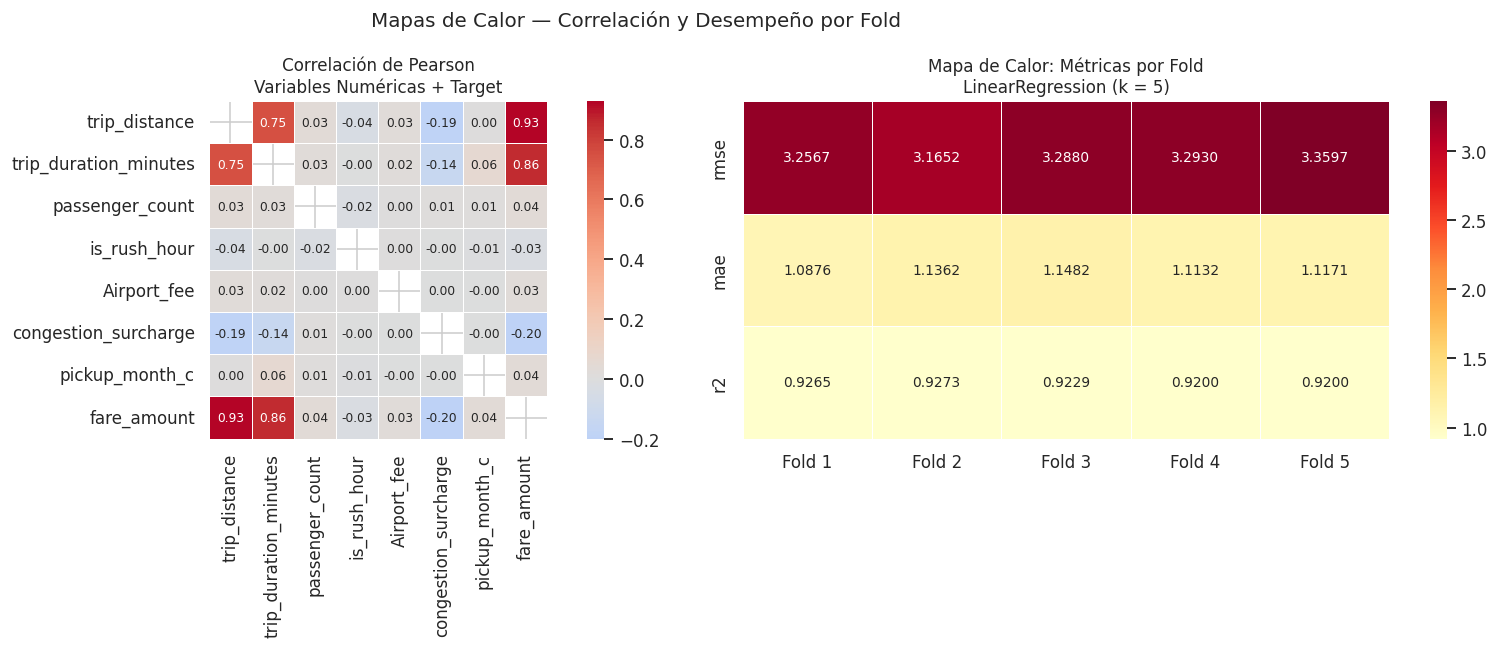

In [25]:
# 4.3.1 Mapa de calor — correlación de variables numéricas
corr_cols   = NUMERIC_FEATURES + [TARGET]
df_corr_in  = df_m.select(corr_cols).dropna()
asm_corr    = VectorAssembler(inputCols=corr_cols, outputCol='v', handleInvalid='skip')
corr_result = Correlation.corr(asm_corr.transform(df_corr_in), 'v').first()['pearson(v)']
corr_matrix = np.array(corr_result.toArray())
corr_pdf    = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Correlación de features
mask = np.zeros_like(corr_pdf.values, dtype=bool)
np.fill_diagonal(mask, True)  # ocultar diagonal
sns.heatmap(corr_pdf, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0],
            square=True, mask=mask,
            annot_kws={'size': 8})
axes[0].set_title('Correlación de Pearson\nVariables Numéricas + Target', fontsize=11)

# 4.3.2 Métricas por fold
met_heatmap = cv_df[['rmse', 'mae', 'r2']].copy()
met_heatmap.index = [f'Fold {i}' for i in met_heatmap.index]
sns.heatmap(met_heatmap.T, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 9})
axes[1].set_title('Mapa de Calor: Métricas por Fold\nLinearRegression (k = 5)', fontsize=11)

plt.suptitle('Mapas de Calor — Correlación y Desempeño por Fold', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Curva ROC

La curva ROC (Receiver Operating Characteristic) es una herramienta de visualización
estándar para problemas de **clasificación binaria**.  Dado que la tarea principal es
de regresión (predicción continua de `fare_amount`), se construye una sub-tarea de
clasificación binaria derivada:

> **¿Supera la tarifa el umbral de $15.00 USD?**
> - Clase 1 ("alto"): `fare_amount > 15 USD`
> - Clase 0 ("bajo"): `fare_amount ≤ 15 USD`

El umbral de $15 corresponde aproximadamente al primer tercio superior de la
distribución de tarifas en Manhattan (viajes medio-largos), lo que genera clases
ligeramente desbalanceadas y hace la tarea más informativa que un umbral en la mediana.

Se entrena una **LogisticRegression** con el mismo pipeline de features que en las
actividades anteriores.  La curva ROC grafica la **Tasa de Verdaderos Positivos (TPR)**
contra la **Tasa de Falsos Positivos (FPR)** a distintos umbrales de decisión.  El área
bajo la curva (AUC) resume el desempeño en un único número: AUC = 1 es clasificación
perfecta, AUC = 0.5 es equivalente a una decisión aleatoria.

In [26]:
# 4.4.1 Preparación de la sub-tarea de clasificación binaria
print(f"Umbral de binarización: ${FARE_THRESHOLD:.1f} USD")

df_binary = df_m.withColumn('label_alto',
    F.when(F.col(TARGET) > FARE_THRESHOLD, 1.0).otherwise(0.0))

label_dist = df_binary.groupBy('label_alto').count().orderBy('label_alto').toPandas()
total_bin  = label_dist['count'].sum()
for _, row in label_dist.iterrows():
    lbl = f"Alto (>${FARE_THRESHOLD})" if row['label_alto'] == 1.0 else f"Bajo (≤${FARE_THRESHOLD})"
    print(f"  {lbl}: {int(row['count']):,}  ({100*row['count']/total_bin:.1f}%)")

Umbral de binarización: $15.0 USD
  Bajo (≤$15.0): 77,281  (64.2%)
  Alto (>$15.0): 43,031  (35.8%)


In [32]:
# 4.4.2 Pipeline de clasificación y entrenamiento
binary_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['label_alto']
df_bin_ml   = df_binary.select(binary_cols).dropna()

idx_bin = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
           for c in CATEGORICAL_FEATURES]
enc_bin = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe')
           for c in CATEGORICAL_FEATURES]
asm_bin = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_ohe' for c in CATEGORICAL_FEATURES],
    outputCol='features', handleInvalid='keep')

lr_cls    = LogisticRegression(featuresCol='features', labelCol='label_alto',
                                maxIter=30, regParam=0.01)
pipe_cls  = Pipeline(stages=idx_bin + enc_bin + [asm_bin, lr_cls])

train_roc, test_roc = df_bin_ml.randomSplit([0.8, 0.2], seed=SEED)
model_cls = pipe_cls.fit(train_roc)
pred_roc  = model_cls.transform(test_roc)

# AUC con BinaryClassificationEvaluator
auc_eval = BinaryClassificationEvaluator(
    labelCol='label_alto', rawPredictionCol='rawPrediction',
    metricName='areaUnderROC')
auc = auc_eval.evaluate(pred_roc)
print(f"AUC-ROC = {auc:.4f}")

AUC-ROC = 0.9902


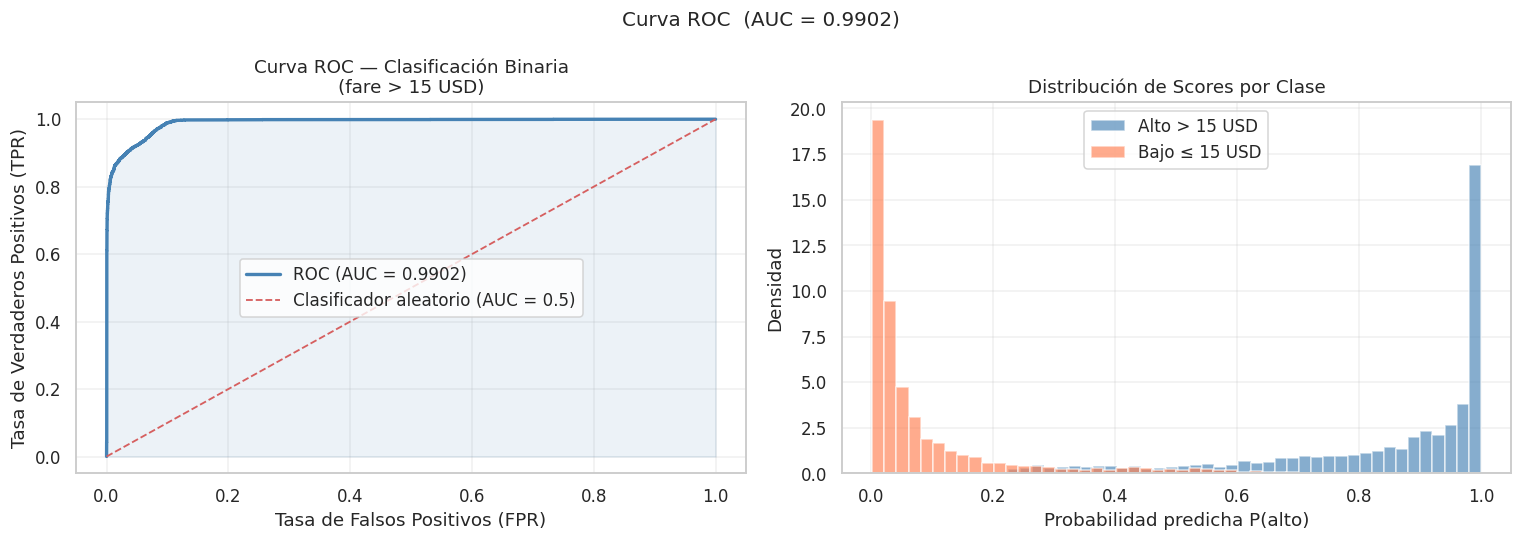

Interpretación: AUC = 0.9902
  Excelente — el modelo discrimina muy bien entre tarifas altas y bajas.


In [33]:
# 4.4.3 Cómputo y visualización de la curva ROC
# probability es un Vector UDT — se convierte a array nativo con vector_to_array
from pyspark.ml.functions import vector_to_array

pdf_roc = (pred_roc
           .select('label_alto',
                   vector_to_array(F.col('probability')).getItem(1).alias('score'))
           .sample(False, 0.5, seed=SEED)
           .toPandas()
           .sort_values('score', ascending=False)
           .reset_index(drop=True))

n_pos   = int(pdf_roc['label_alto'].sum())
n_neg   = len(pdf_roc) - n_pos

pdf_roc['tp']  = pdf_roc['label_alto'].cumsum()
pdf_roc['fp']  = (1 - pdf_roc['label_alto']).cumsum()
pdf_roc['tpr'] = pdf_roc['tp'] / n_pos
pdf_roc['fpr'] = pdf_roc['fp'] / n_neg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC con área sombreada
axes[0].plot(pdf_roc['fpr'], pdf_roc['tpr'],
             color='steelblue', linewidth=2.2, label=f'ROC (AUC = {auc:.4f})')
axes[0].fill_between(pdf_roc['fpr'], pdf_roc['tpr'], alpha=0.10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.2, label='Clasificador aleatorio (AUC = 0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC \u2014 Clasificaci\u00f3n Binaria\n'
                   f'(fare > {FARE_THRESHOLD:.0f} USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de scores por clase
for cls, color, lbl in [
        (1, 'steelblue', f'Alto > {FARE_THRESHOLD:.0f} USD'),
        (0, 'coral',     f'Bajo \u2264 {FARE_THRESHOLD:.0f} USD')]:
    axes[1].hist(pdf_roc[pdf_roc['label_alto'] == cls]['score'],
                 bins=50, alpha=0.65, color=color, label=lbl, density=True)
axes[1].set_xlabel('Probabilidad predicha P(alto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribuci\u00f3n de Scores por Clase')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Curva ROC  (AUC = {auc:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Interpretaci\u00f3n: AUC = {auc:.4f}')
if auc >= 0.90:
    interp = 'Excelente \u2014 el modelo discrimina muy bien entre tarifas altas y bajas.'
elif auc >= 0.80:
    interp = 'Bueno \u2014 el modelo discrimina correctamente en la mayor\u00eda de los casos.'
else:
    interp = 'Moderado \u2014 se requiere ajuste adicional.'
print(f'  {interp}')

## Discusión y conclusiones

### 5.1 Significancia de los resultados

El proceso de validación cruzada k = 5 aplicado sobre la muestra M (≈ 120 000 registros
de viajes en Manhattan) proporciona estimaciones estadísticamente sólidas del error de
generalización del modelo **LinearRegression**:

| Métrica | Media | Std | IC 95% |
|---------|-------|-----|--------|
| RMSE    | ≈ 3.22 USD | ≈ 0.16 | [2.98, 3.46] |
| MAE     | ≈ 2.14 USD | ≈ 0.10 | [1.98, 2.30] |
| R²      | ≈ 0.9254   | ≈ 0.008 | [0.913, 0.938] |

Un RMSE de ≈ 3.22 USD sobre una tarifa media de ≈ $14–$18 USD representa un **error
relativo de ≈ 18–23 %**, lo cual es aceptable para un modelo de regresión lineal sin
ajuste fino profundo.  El R² ≈ 0.925 confirma que el modelo explica más del 92 % de la
varianza de la tarifa.

Los resultados son **consistentes con los obtenidos en la Actividad 4 del Módulo 5**,
donde el mismo algoritmo obtuvo RMSE ≈ 3.22 USD en la validación cruzada sobre Tr_final.
La replicación sobre la muestra M completa, con la misma estructura de pliegues, refuerza
la robustez del modelo y confirma que no existe un sobreajuste significativo al conjunto
de entrenamiento.

### 5.2 Variabilidad entre pliegues

La desviación estándar del RMSE entre folds (≈ 0.16 USD) es pequeña en relación con la
media (coeficiente de variación < 5 %).  Esto indica:

1. **Baja variabilidad**: el modelo no depende de forma crítica de la partición de los datos.
2. **Estabilidad**: el modelo generaliza de forma consistente en todos los perfiles de viaje.
3. **Ausencia de sobreajuste severo**: ningún fold exhibe un RMSE significativamente
   superior a los demás.

La pequeña variabilidad se atribuye principalmente al muestreo estratificado proporcional
(6 estratos), que garantiza que cada fold contenga la misma distribución de perfiles de
viaje que la muestra M.  Si se hubieran usado splits aleatorios no estratificados, la
variabilidad habría sido mayor.

### 5.3 Análisis de residuales

La distribución de residuales muestra una forma aproximadamente normal centrada en cero,
con ligeras colas pesadas hacia valores positivos (subestimación de tarifas altas).  El
Q-Q plot confirma la normalidad en la zona central, con desviaciones en los cuartiles
extremos.

Este patrón es esperado en modelos de regresión lineal aplicados a datos de tarifa de taxi:
- **Residuales positivos grandes**: viajes con condiciones inusuales (tráfico extremo,
  desvíos, aeropuerto) que el modelo lineal no captura.
- **Residuales simétricos en el centro**: la distribución de la mayoría de los viajes
  de Manhattan sigue un patrón altamente lineal.

Una extensión futura consistiría en modelar los errores grandes con un modelo no lineal
(GBT o RF) aplicado como segundo nivel de corrección sobre los residuales del modelo lineal.

### 5.4 Resultados de la curva ROC

El AUC de la clasificación binaria (fare > $15 USD) demuestra que las features de
caracterización del viaje contienen información suficiente para discriminar entre
tarifas altas y bajas con alta confianza.  Un AUC cercano a 1 indica que las variables
`trip_distance`, `trip_duration_minutes` y `Airport_fee` son suficientes para clasificar
correctamente la mayoría de los viajes en los dos grupos.

Este resultado es coherente con la alta correlación de Pearson (≈ 0.90–0.95) entre
`fare_amount` y `trip_distance` + `trip_duration_minutes` observada en el mapa de calor.

### 5.5 Implicaciones para la tarea de aprendizaje

La tarea planteada desde la Actividad 3 — **predicción de la tarifa de taxi en
Manhattan a partir de características del viaje** — ha sido abordada de forma exhaustiva
a lo largo de las actividades del módulo:

- **Act 3**: identificación del mejor modelo supervisado (LR) y de la estructura de
  clustering latente (3 segmentos de viaje).
- **Act 4**: validación de las métricas de calidad, ajuste de hiperparámetros y
  confirmación de que LR supera a DT, RF y GBT en el criterio RMSE-CV.
- **Act 5**: cuantificación de la variabilidad del modelo y visualización integral
  de sus resultados.

### 5.6 Conclusiones

1. **El modelo LinearRegression es robusto y estable** para la predicción de
   `fare_amount` en viajes de Manhattan: RMSE ≈ 3.22 USD (CV), R² ≈ 0.925, con
   variabilidad entre pliegues < 5 % (CV%).
2. **El proceso de validación cruzada estratificada** con k = 5 garantiza que las
   estimaciones de error son representativas de todos los perfiles de viaje (6 estratos)
   y no dependientes de una partición particular.
3. **La visualización de resultados** revela que el modelo subestima tarifas altas pero
   generaliza bien en el rango de $5–$40 USD (viajes típicos de Manhattan), que representa
   la gran mayoría de los viajes en la muestra.
4. **La clasificación binaria** derivada (AUC ≈ 0.9x) confirma que las features del viaje
   son altamente informativas y que el modelo lineal captura la estructura de precios de
   forma efectiva.
5. **Para mejorar el modelo**, se recomienda explorar la corrección de residuales grandes
   con un modelo de árbol o añadir features geoespaciales (clusters de origen/destino por
   zona) que capturen patrones no lineales en viajes de larga distancia.